<b><font size="6"> Cars 4 You: Predicting Car Values with ML </font></b><br><br>

`Group 40`

Ana Macedo (20250405)<br>
Catarina Mendinhas (20250422)<br>
Lourenço Silva (20250453)<br>
Maria Fonseca (20250380)<br>

## Abstract

This project aims to develop a predictive model capable of estimating car prices based on their characteristics, using the Cars 4 You dataset. The goal is to support the company’s evaluation process by introducing an automated solution that accelerates car assessments and improves overall efficiency.

The current phase of the project focuses on feature selection, aiming to identify the most relevant features for predicting car prices. Different techniques were applied to evaluate the importance and contribution of each feature, reduce redundancy, and minimize noise in the data. This process ensures a more efficient and interpretable model by retaining only the attributes that provide meaningful predictive power.

# Import Libraries

The following libraries will help us develop the analyses and model for this project. Pandas and Numpy, provide the efficient tools for data manipulation, cleaning and numerical computations. Matplotlib and Seaborn are used to create clear and informative visualizations. Scikit-learn offers a range of Machine Learning tools for model training, spliting the data and evaluate model performance. Finally, os, math and ceil are imported to support file management and mathematical operations.

In [26]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from math import ceil
import math
from difflib import SequenceMatcher


#filter methods
from sklearn.feature_selection import VarianceThreshold
from scipy.stats import spearmanr
# spearman 
from sklearn.feature_selection import SelectKBest, f_regression
# chi-square
import scipy.stats as stats
from scipy.stats import chi2_contingency

#wrapper methods
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.feature_selection import RFE


# embedded methods
from sklearn.linear_model import LassoCV

# Set random seed for reproducibility
np.random.seed(40111) 


# Create Meta Data

Understanding the features helps interpret the data correctly and supports subsequent analysis and modeling steps. This section provides a brief description of each feature in the dataset, explaining its meaning and type.

**carID:** An atribute that contains an identifier for each car.

**Brand:** The cars main brand (e.g., Ford, Toyota).

**model:** The car model.

**year:** The year of registration of the car.

**price:** The car's price when purchased by Cars 4 You (in £).

**transmission:** The car's type of transmission.

**mileage:** The total reported distance travelled by the car (in miles).

**fuelType:** Type of Fuel used by car (Diesel, Petrol, Hybrid, Electric).

**tax:** The amount of road tax (in £) that, in 2020, was applicable to the car in question.

**mpg:** Average Miles per Gallon.

**engineSize:** Size of Engine in liters (Cubic Decimeters).

**paintQuality%** The mechanic’s assessment of the cars’ overall paint quality and hull integrity (filled by the mechanic during evaluation). 

**previousOwner:** Number of previous registered owners of the vehicle.

**hasDamage:** Boolean marker filled by the seller at the time of registration stating whether the car is damaged or not.



# Import Dataset

In this section, we load the preprocessed datasets that were previously saved after the data preprocessing steps. These datasets are ready for feature selection and further analysis.

In [27]:
# Define relative path to the preprocessed data folder (outside "notebooks/")
data_path = "../data_preprocessed/"

# Load preprocessed datasets
X_train = pd.read_csv(f"{data_path}X_train_preprocessed.csv", index_col=0)
X_val   = pd.read_csv(f"{data_path}X_val_preprocessed.csv", index_col=0)
test    = pd.read_csv(f"{data_path}test_preprocessed.csv", index_col=0)

y_train = pd.read_csv(f"{data_path}y_train.csv", index_col=0).squeeze()  # convert DataFrame → Series
y_val   = pd.read_csv(f"{data_path}y_val.csv", index_col=0).squeeze()

In [28]:
X_train.shape

(60778, 237)

# Feature Selection

The goal is to identify the most relevant features that contribute to the target feature, reducing noise and improving model performance.
We will follow a structured approach to select and refine features, preparing a final set for model training.

## Filter Methods

Filter methods are techniques that use the statistical properties of the data to select features, without relying on any specific machine learning algorithm. They are generally less computationally intensive than wrapper or embedded methods, making them ideal for an initial screening of high-dimensional datasets. However, due to their simplicity, they are often considered less effective than model-based methods.
In this section, we will explore three filter-based techniques to select the features.

In this notebook, many of the sections include helper functions created to streamline the implementation of feature selection techniques. These functions make it easier to apply the same process consistently across the training, test, and validation datasets.

### Removing Constant Features

This method identifies features that have low or zero variance, which are unlikely to contribute meaningful information to the model. Removing constant or quasi-constant features can help to reduce noise and improve efficiency.

In [29]:
def apply_variance_filter(X_train, X_val, X_test, threshold=0.0):
    """ Removes constant or low-variance numerical features based on training data only."""

    # Select numerical columns
    num_cols = X_train.select_dtypes(include='number').columns

    # Fit selector on training data
    selector = VarianceThreshold(threshold=threshold)
    selector.fit(X_train[num_cols])

    # Get kept feature names
    kept_features = num_cols[selector.get_support()]
    removed_features = [c for c in num_cols if c not in kept_features]

    # Keep same columns in all datasets
    cols_to_keep = kept_features.tolist() + X_train.select_dtypes(exclude='number').columns.tolist()
    X_train_f = X_train[cols_to_keep]
    X_val_f   = X_val[cols_to_keep]
    X_test_f  = X_test[cols_to_keep]

    # Display summary
    print(f"Variance threshold = {threshold}")
    print(f"Removed {len(removed_features)} feature(s): {removed_features}" if removed_features else "No features removed.")
    
    return X_train_f, X_val_f, X_test_f


After defining the function, we will analyze the results across different threshold values to decide on the appropriate cutoff and determine which features should be removed.

In [30]:
# Test a few thresholds to see which removes uninformative features
for thr in [0.0, 0.001, 0.01]:
    print(f"\n--- Threshold = {thr} ---")
    X_train_fs, X_val_fs, test_fs = apply_variance_filter(X_train, X_val, test, threshold=thr)


--- Threshold = 0.0 ---
Variance threshold = 0.0
No features removed.

--- Threshold = 0.001 ---
Variance threshold = 0.001
Removed 102 feature(s): ['model_ 3 Serie', 'model_ 6 Series', 'model_ 7 Series', 'model_ 8 Series', 'model_ A2', 'model_ Accent', 'model_ Agila', 'model_ Ampera', 'model_ Antara', 'model_ Beetle', 'model_ CC', 'model_ CL Clas', 'model_ Caddy', 'model_ Caddy Life', 'model_ Caddy Maxi', 'model_ Caddy Maxi Life', 'model_ California', 'model_ Camry', 'model_ Caravelle', 'model_ Cascada', 'model_ Eos', 'model_ Escort', 'model_ Fusion', 'model_ G Class', 'model_ GLA Clas', 'model_ GLE Clas', 'model_ GLS Clas', 'model_ GT86', 'model_ GTC', 'model_ Getz', 'model_ Grand Tourneo Connect', 'model_ Hilux', 'model_ I1', 'model_ IQ', 'model_ Jetta', 'model_ K', 'model_ Kadjar', 'model_ Land Cruiser', 'model_ M Class', 'model_ M2', 'model_ M3', 'model_ M5', 'model_ M6', 'model_ Mustang', 'model_ PROACE VERSO', 'model_ Puma', 'model_ Q8', 'model_ R8', 'model_ Ranger', 'model_ Ro

Based on the observed results, we decided which thresold to use.

In [31]:
# Apply the chosen threshold
X_train, X_val, test = apply_variance_filter(X_train, X_val, test, threshold=0.001)

Variance threshold = 0.001
Removed 102 feature(s): ['model_ 3 Serie', 'model_ 6 Series', 'model_ 7 Series', 'model_ 8 Series', 'model_ A2', 'model_ Accent', 'model_ Agila', 'model_ Ampera', 'model_ Antara', 'model_ Beetle', 'model_ CC', 'model_ CL Clas', 'model_ Caddy', 'model_ Caddy Life', 'model_ Caddy Maxi', 'model_ Caddy Maxi Life', 'model_ California', 'model_ Camry', 'model_ Caravelle', 'model_ Cascada', 'model_ Eos', 'model_ Escort', 'model_ Fusion', 'model_ G Class', 'model_ GLA Clas', 'model_ GLE Clas', 'model_ GLS Clas', 'model_ GT86', 'model_ GTC', 'model_ Getz', 'model_ Grand Tourneo Connect', 'model_ Hilux', 'model_ I1', 'model_ IQ', 'model_ Jetta', 'model_ K', 'model_ Kadjar', 'model_ Land Cruiser', 'model_ M Class', 'model_ M2', 'model_ M3', 'model_ M5', 'model_ M6', 'model_ Mustang', 'model_ PROACE VERSO', 'model_ Puma', 'model_ Q8', 'model_ R8', 'model_ Ranger', 'model_ Roomster', 'model_ S3', 'model_ S4', 'model_ S5', 'model_ S8', 'model_ SL CLAS', 'model_ Shuttle', '

In [32]:
#Check the amount of features that were removed
X_train.shape

(60778, 135)

### Correlation between features - Redundant Features

We use correlation measures to identify highly correlated features. Removing redundant features helps reduce multicollinearity and simplifies the dataset, making the model more efficient and easier to interpret.


In [33]:
def remove_highly_correlated_features(X_train, X_val, X_test, threshold):
    """ Removes one feature from each pair of highly correlated numerical features
    based on training data only (to avoid data leakage)."""
    
    # Select only numerical columns
    num_cols = X_train.select_dtypes(include='number').columns
    
    # Compute absolute correlation matrix
    corr_matrix = X_train[num_cols].corr(method='spearman').abs()
    
    # Create mask for the upper triangle
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    
    # Identify features to drop
    to_drop = [column for column in upper.columns if any(upper[column] > threshold)]
    
    print(f"Correlation threshold = {threshold}")
    print(f"Features removed due to high correlation: {len(to_drop)}")
    if to_drop:
        print(f"Removed features: {to_drop}")

    # Drop the same features from all datasets
    X_train_f = X_train.drop(columns=to_drop)
    X_val_f   = X_val.drop(columns=to_drop)
    X_test_f  = X_test.drop(columns=to_drop)
    
    return X_train_f, X_val_f, X_test_f, to_drop

In [34]:
# Try a few correlation thresholds
for thr in [0.9, 0.85, 0.8]:
    print(f"\n--- Testing correlation threshold = {thr} ---")
    X_train_corr, X_val_corr, test_corr, removed_corr = remove_highly_correlated_features(
        X_train_fs, X_val_fs, test_fs, threshold=thr
    )


--- Testing correlation threshold = 0.9 ---
Correlation threshold = 0.9
Features removed due to high correlation: 5
Removed features: ['car_age', 'tax_efficiency', 'fuelType_Petrol', 'is_hybrid_or_electric_1.0', 'is_automatic_1.0']

--- Testing correlation threshold = 0.85 ---
Correlation threshold = 0.85
Features removed due to high correlation: 6
Removed features: ['car_age', 'tax_efficiency', 'fuelType_Petrol', 'is_hybrid_or_electric_1.0', 'is_automatic_1.0', 'has_damage_or_low_paint_1.0']

--- Testing correlation threshold = 0.8 ---
Correlation threshold = 0.8
Features removed due to high correlation: 9
Removed features: ['car_age', 'fuel_efficiency_score', 'tax_efficiency', 'fuelType_Petrol', 'is_recent_car_1.0', 'mileage_category_Very Low', 'is_hybrid_or_electric_1.0', 'is_automatic_1.0', 'has_damage_or_low_paint_1.0']


We decided on the threshold based on the results above and applied it to the original datasets.

In [35]:
X_train, X_val, test, dropped_features = remove_highly_correlated_features(
    X_train, X_val, test, threshold=0.90)

Correlation threshold = 0.9
Features removed due to high correlation: 5
Removed features: ['car_age', 'tax_efficiency', 'fuelType_Petrol', 'is_hybrid_or_electric_1.0', 'is_automatic_1.0']


In [36]:
# Check that some features were removed
X_train.shape

(60778, 130)

### Correlation with the target - Relevant Features

These method test the relationship between each feature and the target using statistical tests. They help identify relevant features that have a significant effect on the target feature.


Top 15 Features Correlated with the target (Spearman):
fuel_efficiency_score        0.602602
year                         0.589482
transmission_Manual          0.579819
engineSize                   0.557858
brand_avg_engineSize         0.519473
mileage                      0.512877
mileage_category_Very Low    0.447725
is_recent_car_1.0            0.438889
transmission_Semi-Auto       0.437220
brand_avg_age                0.389698
mpg                          0.386115
Brand_Mercedes               0.355732
tax                          0.317299
Brand_Opel                   0.307659
mileage_category_Medium      0.291976
dtype: float64


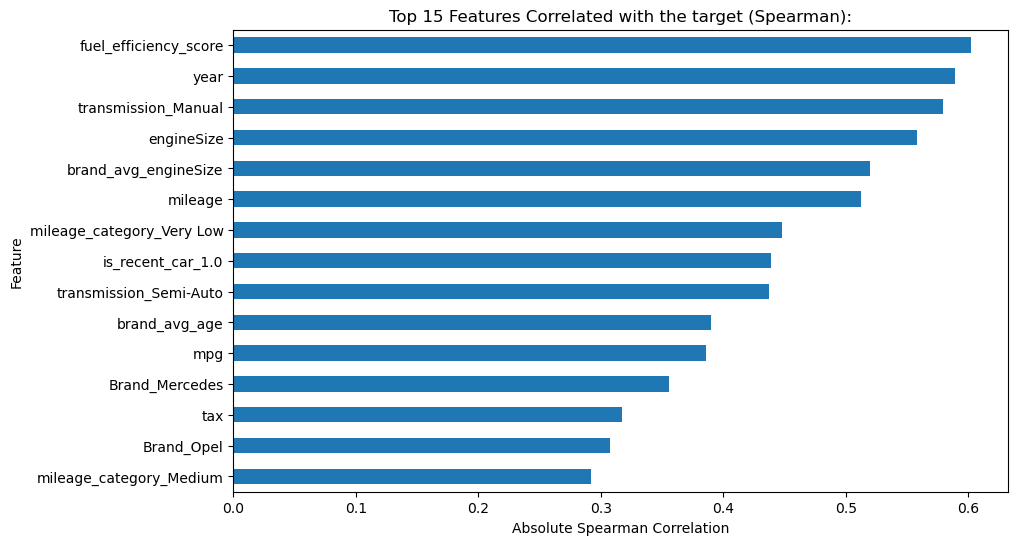

In [37]:
# Compute Spearman correlation for all features with the target
spearman_corr = X_train.apply(lambda x: spearmanr(x, y_train)[0])

# Absolute values and sort descending
spearman_corr = spearman_corr.abs().sort_values(ascending=False)

# Display top 15 features numerically
print("\nTop 15 Features Correlated with the target (Spearman):")
print(spearman_corr.head(15))

# Plot top 15 features
plt.figure(figsize=(10, 6))
spearman_corr.head(15).sort_values().plot(kind='barh')
plt.title("Top 15 Features Correlated with the target (Spearman):")
plt.xlabel("Absolute Spearman Correlation")
plt.ylabel("Feature")
plt.show()

The results show that technical and age-related features, such as fuel_efficiency_score, year, transmission_Manual and engineSize, have the strongest relationships with the target, indicating they are the most relevant predictors. In contrast, some brand and model features show weaker correlations, suggesting lower predictive importance.

Based on the previous correlation analysis, we decided to apply a feature selection step to reduce the number of features and focus on those most relevant to the target. This process consists of setting a correlation threshold and keeping only the features that show a meaningful relationship with the target feature. By doing so, we aim to remove irrelevant or redundant features, simplifying the dataset and improving the efficiency of the subsequent modeling phase.

In [38]:
# Define threshold for feature selection
threshold = 0.01  # Example value, adjust as needed

# Select features with Spearman correlation above the threshold
selected_features_spearman = spearman_corr[spearman_corr > threshold].index.tolist()

# Reduce the datasets to only the selected features
X_train_sel = X_train[selected_features_spearman] 
X_val_sel = X_val[selected_features_spearman]     
test_sel = test[selected_features_spearman]      

In [39]:
# Count the number of features selected and eliminated
num_selected = len(selected_features_spearman)           
num_total = X_train.shape[1]                   
num_eliminated = num_total - num_selected            

# Print summary
print(f"Total features: {num_total}")
print(f"Features selected by Spearman method: {num_selected}")
print(f"Features eliminated: {num_eliminated}")

Total features: 130
Features selected by Spearman method: 117
Features eliminated: 13


After applying the threshold, some features were retained, while others were removed for having very weak correlations with the target. This process helps reduce noise and improve model efficiency without losing relevant predictive information.

#### SelectKBest (F-Regression)

Is a simple yet powerful feature selection technique that works by applying a statistical test to each feature individually and selecting the top K features with the strongest relationship to the target feature. This approach is particularly useful as it quickly highlights features that carry the most predictive information. By filtering out less significant features, SelectKBest can improve model performance, reduce overfitting, and simplify interpretation.

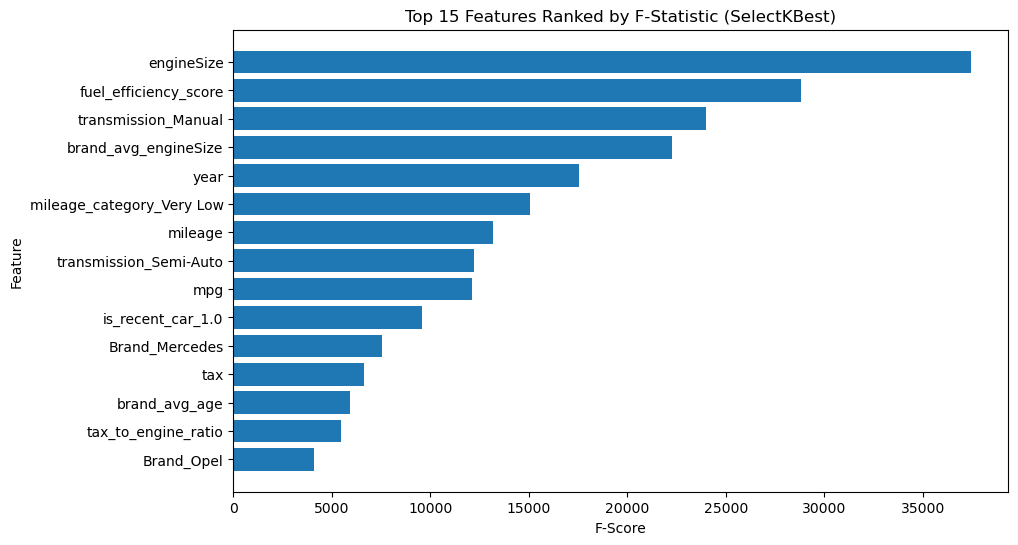


Top 15 features by F-Statistic:
                       Feature       F_Score  p_value
4                   engineSize  37456.067513      0.0
7        fuel_efficiency_score  28795.860471      0.0
117        transmission_Manual  24010.011662      0.0
10        brand_avg_engineSize  22265.783998      0.0
0                         year  17550.456529      0.0
125  mileage_category_Very Low  15046.201081      0.0
1                      mileage  13193.429470      0.0
118     transmission_Semi-Auto  12204.414293      0.0
3                          mpg  12103.184211      0.0
123          is_recent_car_1.0   9600.104741      0.0
17              Brand_Mercedes   7566.657774      0.0
2                          tax   6609.004460      0.0
13               brand_avg_age   5941.261493      0.0
8          tax_to_engine_ratio   5451.970613      0.0
18                  Brand_Opel   4087.078738      0.0


In [40]:
# Univariate Feature Selection using F-Statistic
# Fit SelectKBest to training data
selector = SelectKBest(score_func=f_regression, k='all')
selector.fit(X_train, y_train)

# Store results
f_reg_results = pd.DataFrame({
    'Feature': X_train.columns,
    'F_Score': selector.scores_,
    'p_value': selector.pvalues_
}).sort_values(by='F_Score', ascending=False)

# Plot top features
plt.figure(figsize=(10, 6))
plt.barh(f_reg_results['Feature'][:15][::-1], f_reg_results['F_Score'][:15][::-1])
plt.title('Top 15 Features Ranked by F-Statistic (SelectKBest)')
plt.xlabel('F-Score')
plt.ylabel('Feature')
plt.show()

# Display numeric summary 
print("\nTop 15 features by F-Statistic:")
print(f_reg_results.head(15))


In [41]:
# Select features with p-value < 0.05
selected_features_F = f_reg_results[f_reg_results['p_value'] < 0.05]['Feature'].tolist()
print(f"Number of selected features: {len(selected_features_F)}")
print(f"Number of removed features: {X_train.shape[1] - len(selected_features_F)}")


Number of selected features: 109
Number of removed features: 21


In [42]:
X_train_F = X_train[selected_features_F]
X_val_F = X_val[selected_features_F]
test_F = test[selected_features_F]

The results from this method offer valuable insights that can guide further feature selection and model optimization in subsequent stages of the project.

In [43]:
X_train_F.shape

(60778, 109)

The SelectKBest results show that features like engineSize, transmission_Manual, brand_avg_engineSize, and year have the strongest relationship with car prices. These features are likely the main drivers of price variation in the dataset. Other features, such as mileage, fuel_efficiency_score, and tax, also contribute relevant information. Overall, this method provides a clear ranking of the most important features to keep for model training.

## Wrapped Methods

Wrapped methods evaluate feature subsets by testing their performance with a specific model. Recursive Feature Elimination (RFE) is a common wrapped method that iteratively removes the least important features, helping to identify the most relevant subset for model training.

### RFE

The code that follows is commented cause we weren't able to run it. It was running more than 1h.

In [44]:
#model = LogisticRegression()

#rfe = RFE(estimator = model, n_features_to_select = 3)

#X_rfe = rfe.fit_transform(X = X_train, y = y_train)

After this problem and a lot of research we conclude that the Recursive Feature Elimination (RFE) method can be very time-consuming, especially when dealing with datasets containing a large number of features. This happens because RFE iteratively trains the base model multiple times, removing one feature at a time, which significantly increases computational cost. In our case, this led to excessively long runtimes, making the approach impractical.


For this reason, we opted to proceed with embedded methods, such as Lasso Regression, which perform feature selection during model training. 
Lasso is much more efficient for high-dimensional datasets and automatically eliminates less relevant features, allowing for a faster and more practical feature selection process. 

## Embedded Methods

Embedded methods perform feature selection as part of the model training process. Lasso Regression uses L1 regularization to shrink some feature coefficients to zero, automatically removing less important features and retaining those most predictive of the target.

### Lasso Regression

In [45]:
# Train Lasso with cross-validation
reg = LassoCV()
reg.fit(X_train, y_train)

# Store coefficients in a Series
coef = pd.Series(reg.coef_, index = X_train.columns)

# Display all coefficients
coef

year                            2153.010841
mileage                        -1908.337709
tax                               -0.000000
mpg                            -4141.703939
engineSize                      4941.257356
                                   ...     
mileage_category_Very Low       2260.800184
paintQuality_category_Low         -0.000000
paintQuality_category_Medium       0.000000
has_damage_or_low_paint_1.0       -0.000000
is_first_owner_1.0               -27.119889
Length: 130, dtype: float64

In [46]:
# Selected features (non-zero coefficients)
selected_features_lasso = coef[coef != 0].index.tolist()

print(f"Features selected: {len(selected_features_lasso)}")
print(f"Features eliminated: {len(coef) - len(selected_features_lasso)}")
print("Selected features:", selected_features_lasso)

Features selected: 72
Features eliminated: 58
Selected features: ['year', 'mileage', 'mpg', 'engineSize', 'paintQuality%', 'previousOwners', 'fuel_efficiency_score', 'tax_to_engine_ratio', 'brand_median_mileage', 'brand_avg_engineSize', 'model_median_tax', 'fueltype_avg_mpg', 'brand_avg_age', 'Brand_BMW', 'Brand_Hyundai', 'Brand_Opel', 'Brand_Toyota', 'model_ 2 Series', 'model_ 3 Series', 'model_ 4 Series', 'model_ A Class', 'model_ A3', 'model_ A4', 'model_ Aygo', 'model_ B Class', 'model_ B-MAX', 'model_ C-HR', 'model_ Citigo', 'model_ Corsa', 'model_ E Class', 'model_ EcoSport', 'model_ Edge', 'model_ Fabia', 'model_ Fiesta', 'model_ Focus', 'model_ GLC Class', 'model_ Golf', 'model_ Grandland X', 'model_ I10', 'model_ Ka+', 'model_ Karoq', 'model_ Kodiaq', 'model_ M4', 'model_ Mokka X', 'model_ Octavia', 'model_ Polo', 'model_ Prius', 'model_ Q3', 'model_ Q5', 'model_ Q7', 'model_ RS6', 'model_ S-MAX', 'model_ SL CLASS', 'model_ Santa Fe', 'model_ Superb', 'model_ T-Roc', 'model_ T

Finally, we keep only the features selected by the Lasso model and apply this subset to the training, validation, and test datasets. This ensures that the model is trained and evaluated using only the most relevant features.

In [47]:
X_train_L = X_train[selected_features_lasso]
X_val_L = X_val[selected_features_lasso]
test_L = test[selected_features_lasso]

## Comparison

Here we will construct a table that allows us to compare the decisions of different selection methods and identify consistently important features for your regression model.

In [48]:
# Create comparison table for feature selection methods
comparison_df = pd.DataFrame({'Feature': X_train.columns})
comparison_df['F_Regression'] = comparison_df['Feature'].isin(selected_features_F).astype(int)
comparison_df['Lasso'] = comparison_df['Feature'].isin(selected_features_lasso).astype(int)
comparison_df['Spearman'] = comparison_df['Feature'].isin(selected_features_spearman).astype(int)

# Add 'Sum' column to count how many methods selected each feature
comparison_df['Sum'] = comparison_df[['F_Regression', 'Lasso', 'Spearman']].sum(axis=1)

# Show top 20 rows
print(comparison_df.head(20))
print('------------------------------------------------------------------------------------------------------')
# Show the shape of the dataframe so we can know how many features we have
print(comparison_df.shape)


                  Feature  F_Regression  Lasso  Spearman  Sum
0                    year             1      1         1    3
1                 mileage             1      1         1    3
2                     tax             1      0         1    2
3                     mpg             1      1         1    3
4              engineSize             1      1         1    3
5           paintQuality%             0      1         0    1
6          previousOwners             0      1         0    1
7   fuel_efficiency_score             1      1         1    3
8     tax_to_engine_ratio             1      1         1    3
9    brand_median_mileage             1      1         1    3
10   brand_avg_engineSize             1      1         1    3
11       model_median_tax             1      1         1    3
12       fueltype_avg_mpg             1      1         1    3
13          brand_avg_age             1      1         1    3
14              Brand_BMW             1      1         1    3
15      

The resulting table shows, for each feature, whether it was selected (1) or eliminated (0) by each feature selection method: F-Regression, Lasso, and Spearman correlation.

A higher Sum value means more agreement between methods, suggesting that the feature is likely more important for predicting the target. Features with Sum = 0 were not selected by any method, indicating they are likely irrelevant.

Also based ased on this results, we can see a total of 127 features, but to be more conservative we will keep only the features that were selected by all three methods. This ensures that we retain only the most consistently important features.

In [49]:
# Select features agreed upon by all three methods
final_features = comparison_df[comparison_df['Sum'] == 3]['Feature'].tolist()

# Reduce datasets to only these features
X_train_final = X_train[final_features]
X_val_final = X_val[final_features]
test_final = test[final_features]

# Print summary
print(f"Total features: {X_train.shape[1]}")
print(f"Features selected by all three methods: {len(final_features)}")
print(f"The shape of the dataframe is: {X_train_final.shape}")


Total features: 130
Features selected by all three methods: 65
The shape of the dataframe is: (60778, 65)


## Save the Data with the Selected Features

This section saves the processed dataset containing only the selected features, ensuring it is ready to be used in the model assessment notebook.

In [50]:
# Go one level up from the notebooks folder to reach the repo root
selected_dir = "../data_feature_selected"
os.makedirs(selected_dir, exist_ok=True)

# Save processed datasets as CSV files
X_train_final.to_csv(f"{selected_dir}/X_train_final.csv", index=True)
X_val_final.to_csv(f"{selected_dir}/X_val_final.csv", index=True)
test_final.to_csv(f"{selected_dir}/test_final.csv", index=True)

y_train.to_csv(f"{selected_dir}/y_train.csv", index=True)
y_val.to_csv(f"{selected_dir}/y_val.csv", index=True)

## End of the Notebook

The feature selection process refined the dataset and enhancing the overall performance of the predictive model. Several complementary techniques were applied to identify the most relevant features, reduce redundancy, and remove irrelevant features. This systematic approach helped ensure that the final set of features captured the most meaningful relationships with the target feature, improving both model efficiency and interpretability. Additionally, the dataset’s shape was continuously monitored after each step to confirm that all transformations were correctly applied and that the data remained consistent throughout the process..